# Busqueda de contornos en openCV

En este documento mostraremos como extraer contornos de imagenes binarias usando la biblioteca openCV.

Primero vamos cargar los módulos necesarios, definir algunas constantes y funciones útiles.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Definimos colores para dibujar los niveles de los contornos.
colors = np.array([[255, 255, 255],    # white:    Nivel 1
                   [255,   0,   0],    # Red:      Nivel 2
                   [255,   0, 255],    # Magenta:  Nivel 3
                   [  0, 255,   0],    # Green:    Nivel 4
                   [  0,   0, 255]],   # Rojo:     Nivel 0
                   dtype=np.uint8)

# Esta función calcula la profundidad de un contorno
# de acuerdo a su jerarquía.
def computeDepth(h):
    _, r,_ = h.shape
    d = np.zeros(r, dtype=np.int32)
    for i in range(r):
        cont = 0
        j = i
        while True:
            if h[0, j, 3] != -1:
                j = h[0, j, 3]
                cont += 1
            else:
                break
        d[i] = cont
    return d

## Imagen de prueba

La imagen de prueba es el logo de la organización "[Iglesia del Monstruo Volador del Espagueti](https://www.spaghettimonster.org/)" (FSM por sus siglas en ingles.

Esta imagen es adecuada para demostrar el uso de la rutina ```findContours``` de OpenCV, pues como se puede observar es una figura simple que contiene objetos anidados.


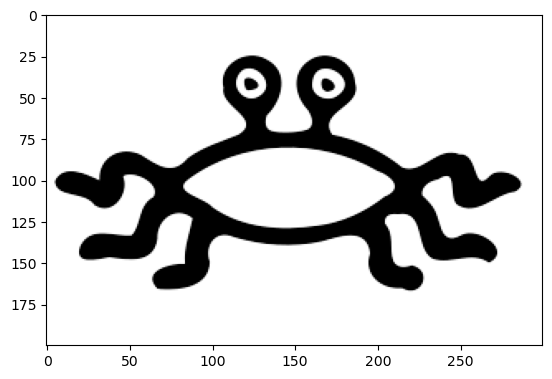

In [3]:
I = cv2.imread('imágenes/FSM_Logo.png',cv2.IMREAD_GRAYSCALE)

# Display the image
fg1, ax1 = plt.subplots()
_ =ax1.imshow(I, cmap='Greys')

# Búsqueda de contornos

La rutina recibe de entrada una imagen binaria y dos parámetros: el modo y el método. Hay un ultimo parámetro opcional, el *offset*, que es util cuando se extraen contornos de una subregion de interés (ROI).


El modo en que se van a extraer los contornos, lo cual está relaciónado principalmente en la forma en que se van a organizar los contornos que se extraigan. Las diferentes modos se demostraran más adelante.

El método se refiere a las forma en que se van a aproximar los contornos de los objetos en la imagen.


La rutina regresa dos estructuras:

 * Contornos: una tupla que contiene los contornos encontrados. Cada contorno es se almacena en una arreglo de numpy de tamaño $1 \times n \times 2$, donde $n$ es el número de pixeles en la imagen que pertenecen al contorno. En este  arreglo cada renglón contiene una coordenada de un pixel que forma parte del contorno. Dichas coordenadas estan ordenadas de tal manera que la topología del contorno se preserve.
 
 
 * Jerarquía: una arreglo de numpy de tamaño $n \times 4$ en donde cada renglon describe la relación jerárquica que mantienen los contorno entre si. Más adelante se describirá dicho arreglo


A continuación invocamos el metodo ```findContours``` y mostramos el resultado.

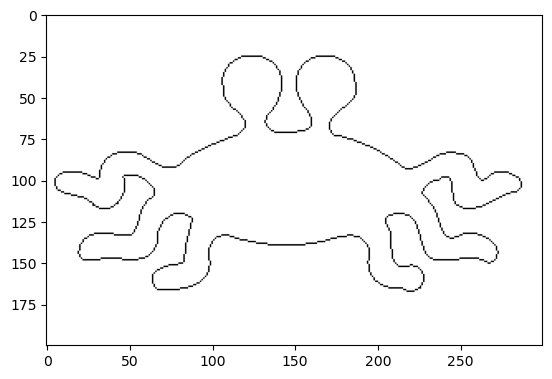

In [4]:
# Invocamos la funcion findContours.
# Nótese que ignoramos por el momento la información jerárquica

contornos, _ = cv2.findContours(I, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)

# El numero de contornos encontrados.

nC = len(contornos)

# Dibujamos los contornos.

O=np.zeros(I.shape,dtype=np.uint8)

for i in range(nC):
    for contCoor in contornos[i]:
        c,r = contCoor[0,:]
        O[r,c] = 255
        
fg2, ax2 = plt.subplots()
ax2.imshow(O, cmap='Greys')
plt.show()

## Jerarquías de contornos.

Al segmentar una imagen puede ser que un objeto tenga huecos, por lo que a dicho objeto les pueden corresponde mas de un contorno: un contorno externo por necesidad y posiblemente uno o más contornos internos. Es posible que ocurra que adentro de un hueco en una imagen exista otro objeto el cual potencialmente puede tener hoyos adentro y así sucesivamente. Vamos a explicar aqui, las formas en que podemos extraer contornos usando ```findContours```, y como las jerarquías se representan.

### Modos de operación.
 
Cuando invocamos la función ```findContours``` existen varios 'modos' de operación, que se describen a continuación:

 * ```RETR_EXTERNAL```: se regresa una lista que contiene solo contiene contornos externos.
 
 * ```RETR_LIST```: se regresan una lista con todos los contornos en la imagen, pero sin especificar relaciónes jerárquicas.
 
 * ```RETR_CCOMP```: se regresa una lista que contiene todos los contornos organizados en una jerarquía de dos niveles: en el primer nivel están todos los contornos externos y en el segundo todos los contornos internos.
 
 * ```RETR_TREE```: se regresa una lista con todos los contorno, tomando en cuenta la organización jerárquica completa entre ellos, en forma de un árbol.


### Representación jerárquica

A cada contorno encontrado se le asocia un arreglo de 4 valores, cada uno indicando el tipo de asociación de un contorno en la lista, de acuerdo a la siguiente tabla:

 
 |  Indice  |           Significado             |
 |:--------:|:----------------------------------|
 | 0 | Contorno siguiente (mismo nivel)         |
 | 1 | Contorno previo (mismo nivel)            |
 | 2 | Primer contorno hijo (un nivel inferior) |
 | 3 | Contorno Padre (un nivel superior)       |
 
 **Tabla 1:** interpretación de información jerárquica de un contorno.
 

 ---

### RETR_EXTERNAL

Solo los contornos externos del objeto se extraen en una lista simple.



Se encontro 1 contorno

El contorno 0 consta de 1228 elementos

Jerarquía de contornos:
 [[[-1 -1 -1 -1]]]


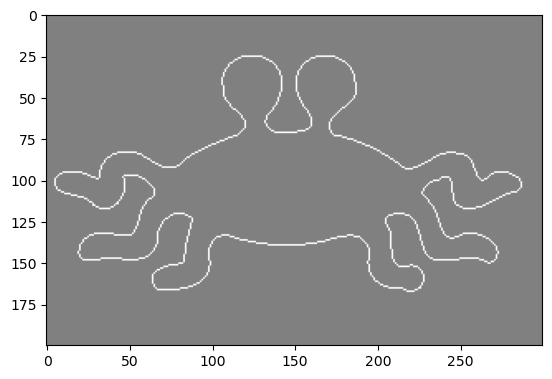

In [5]:
contExternal, hierExternal = cv2.findContours(I, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
nC_External = len(contExternal)

print ("Se encontro %d contorno\n"%nC_External)
for i in range(nC_External):
    print("El contorno %d consta de %d elementos" % (i,contExternal[i].shape[0]))
    
print("\nJerarquía de contornos:\n", hierExternal)


# Dibujamos los contornos.
r,c = I.shape

depthExternal = computeDepth(hierExternal)

OE = 128 * np.ones((r,c,3), dtype=np.uint8)

for i in range(nC_External):
    color = colors[depthExternal[i], :]
    for contCoor in contExternal[i]:
        c, r = contCoor[0, :]
        OE[r,c,:] = color
    
_ = cv2.imwrite("ContornosExternos.png", OE)    
    
fg3, ax3 = plt.subplots()
ax3.imshow(OE,cmap='Greys')
plt.show()



Como se puede observar en la figura, solo el contorno externo del objeto en la imagen se grafíca.

Para este caso, donde solo hay un objeto, la jerarquia representa a un solo objeto, por que la matriz de jerarquías (```hierExternal```), solo contiene un renglón, que en donde los cuatro valores son iguales a $-1$, esto es, no puede haber relaciónes jerárquicas si existe un solo miembro. 

---

### RETR_LIST

Los contornos del objeto se extraen en una lista simple, sin especificar jerarquias. 


Se encontraron 6 contornos

El contorno 0 consta de 260 elementos
El contorno 1 consta de 25 elementos
El contorno 2 consta de 26 elementos
El contorno 3 consta de 51 elementos
El contorno 4 consta de 48 elementos
El contorno 5 consta de 1228 elementos

Jerarquía de contornos:
 [[[ 1 -1 -1 -1]
  [ 2  0 -1 -1]
  [ 3  1 -1 -1]
  [ 4  2 -1 -1]
  [ 5  3 -1 -1]
  [-1  4 -1 -1]]]


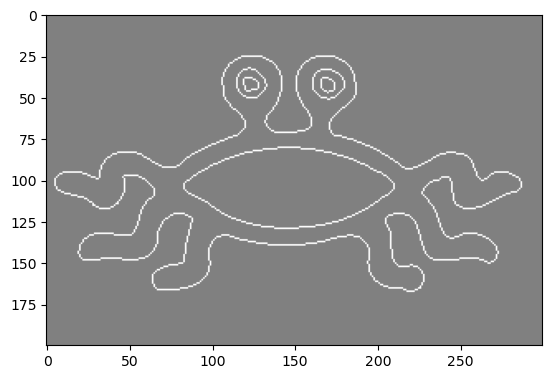

In [6]:
contList, hierList = cv2.findContours(I, cv2.RETR_LIST, cv2.CHAIN_APPROX_NONE)
nC_List = len(contList)

print ("Se encontraron %d contornos\n"%nC_List)
for i in range(nC_List):
    print("El contorno %d consta de %d elementos" % (i,contList[i].shape[0]))
    
print("\nJerarquía de contornos:\n", hierList)

# Dibujamos los contornos.
r,c = I.shape

depthList = computeDepth(hierList)

OL = 128 * np.ones((r,c,3), dtype=np.uint8)

for i in range(nC_List):
    color = colors[depthList[i], :]
    for contCoor in contList[i]:
        c, r = contCoor[0,:]
        OL[r,c,:] = color

fg4, ax4 = plt.subplots()
ax4.imshow(OL, cmap='Greys')
plt.show()

Como se puede observar en la figura, ahora se muestran todos los contornos, usando el mismo color, lo que indica que todos pertenecen al mismo nivel.

Al observar la matriz de Jerarquía, podemos observal que las columnas con indice 2 y 3 contienen únicamente valores $-1$, lo que indica que no hay contornos padres o hijos.

Si observamos que la primera columna (índice 0), notamos que cada valor es el índice del contorno siguiente, *e.g.* al contorno con indice 0 le sigue el contorno con índice 1, a este el contorno con índice 3 y así sucesivamente. El último contorno es igual a $-1$ porque no hay mas contornos después.

De manera reciproca, en la segunda columna (índice 1) cada valor es el índice del contorno que le precede. El valor del primer contorno es $-1$ porque no hay ningun nodo previo.

### RETR_CCOMP

Los contornos del objeto se extraen en una lista, organizado una jerarquía de dos niveles: en el primer nivel contornos externos y en segundo contornos internos.

Se encontraron 6 contornos

El contorno 0 consta de 25 elementos
El contorno 1 consta de 26 elementos
El contorno 2 consta de 1228 elementos
El contorno 3 consta de 260 elementos
El contorno 4 consta de 51 elementos
El contorno 5 consta de 48 elementos

Jerarquía de contornos:
 [[[ 1 -1 -1 -1]
  [ 2  0 -1 -1]
  [-1  1  3 -1]
  [ 4 -1 -1  2]
  [ 5  3 -1  2]
  [-1  4 -1  2]]]


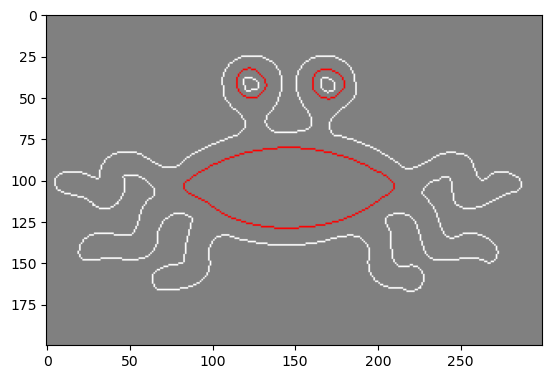

In [7]:
contCcomp, hierCcomp = cv2.findContours(I, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_NONE)
nC_Ccomp = len(contCcomp)

print ("Se encontraron %d contornos\n"%nC_Ccomp)
for i in range(nC_Ccomp):
    print("El contorno %d consta de %d elementos" % (i,contCcomp[i].shape[0]))
    
print("\nJerarquía de contornos:\n", hierCcomp)

# Dibujamos los contornos.
r,c = I.shape

depthCcomp = computeDepth(hierCcomp)

OC = 128 * np.ones((r,c,3), dtype=np.uint8)

for i in range(nC_Ccomp):
    color = colors[depthCcomp[i], :]
    for contCoor in contCcomp[i]:
        c, r = contCoor[0,:]
        OC[r,c,:] = color

fg5, ax5 = plt.subplots()
ax5.imshow(OC, cmap='Greys')
plt.show()

Como se puede observar en la figura, ahora se muestran todos los contornos, organizados en dos niveles: en color rojo los contorno externos, y en color azul los internos.

## Organización de la matriz.

La matriz contiene indices a a la tupla de contornos. Recordemos que si el valor contenido es $-1$, esto indica que la asociación correspondiente no existe.

Analicemos el contenido de la matriz ```hierCcomp```.

### Renglón 0 de la matriz

El primer contorno tiene asociados los valores siguientes:

$$[ 1, -1, -1, -1 ]$$

Esto significa que:

 * $\mathbf{1}$: El índice del contorno siguiente en el mismo nivel es el que tiene el índice $1$.
 * $\mathbf{-1}$: No tiene un contorno previo en el mismo nivel.
 * $\mathbf{-1}$: El índice del contorno hijo es el que tiene el índice $1$.
 * $\mathbf{-1}$: No tiene un contorno padre.

### Renglón 1 de la matriz

El segundo contorno de la matriz tiene asociados los valores siguientes:

$$[ 2,  0, -1, -1 ]$$

Esto significa que:

 * $\mathbf{2}$: El índice del contorno siguiente en el mismo nivel es el que tiene índice $2$.
 * $\mathbf{0}$: El índice del contorno previo en el mismo nivel es el que tiene el índice $0$.
 * $\mathbf{-1}$: No tiene un contorno hijo.
 * $\mathbf{-1}$: No tiene un contorno padre.
 
### Renglón 2 de la matriz

El tercer contorno de la matriz tiene asociados los valores siguientes:

$$[ -1,  1,  3, -1 ]$$

Esto significa que:

 * $\mathbf{-1}$: No tiene un contorno siguiente en el mismo nivel.
 * $\mathbf{1}$: El índice del contorno previo en el mismo nivel es el que tiene índice $1$.
 * $\mathbf{3}$: El índice del contorno hijo es $3$.
 * $\mathbf{-1}$: No tiene un contorno padre.

### Renglón 3 de la matriz

El cuarto contorno de la matriz tiene asociados los valores siguientes:

$$[ 4, -1, -1, 2 ]$$

Esto significa que:

 * $\mathbf{4}$: El índice del contorno siguiente en el mismo nivel es el que tiene índice $4$.
 * $\mathbf{-1}$: No tiene un contorno previo en el mismo nivel.
 * $\mathbf{-1}$: No tiene un contorno hijo.
 * $\mathbf{2}$: El índice del contorno padre es $2$.
 
### Renglón 4 de la matriz

El quinto contorno de la matriz tiene asociados los valores siguientes:

$$[5,  3, -1,  2 ]$$

Esto significa que:

 * $\mathbf{5}$:  El índice del contorno siguiente en el mismo nivel es el que tiene índice $5$.
 * $\mathbf{3}$: El índice del contorno previo en el mismo nivel es el que tiene índice $3$.
 * $\mathbf{-1}$: No tiene un contorno hijo.
 * $\mathbf{2}$: El índice del contorno padre es $2$.

### Renglón 5 de la matriz

El sexto contorno de la matriz tiene asociados los valores siguientes:

$$[ -1, 4, -1, 2 ]$$

Esto significa que:

 * $\mathbf{-1}$: No tiene un contorno siguiente en el mismo nivel.
 * $\mathbf{4}$: El índice del contorno previo en el mismo nivel es el que tiene índice $4$.
 * $\mathbf{-1}$: No tiene un contorno hijo.
 * $\mathbf{2}$: El índice del contorno padre es $2$.
 
### Relacion entre contornos

![image](Diagrama_Jerarquía_Ccomp.png)

### RETR_TREE

Los contornos del objeto se extraen en una lista, organizado una jerarquía de múltiples niveles, organizados en forma de un árbol.

Se encontraron 6 contornos

El contorno 0 consta de 1228 elementos
El contorno 1 consta de 260 elementos
El contorno 2 consta de 51 elementos
El contorno 3 consta de 25 elementos
El contorno 4 consta de 48 elementos
El contorno 5 consta de 26 elementos

Jerarquía de contornos:
 [[[-1 -1  1 -1]
  [ 2 -1 -1  0]
  [ 4  1  3  0]
  [-1 -1 -1  2]
  [-1  2  5  0]
  [-1 -1 -1  4]]]


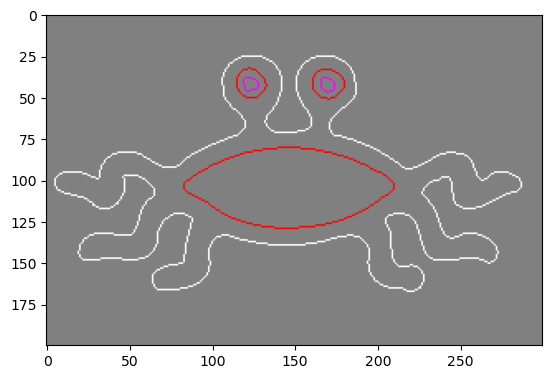

In [8]:
contTree, hierTree = cv2.findContours(I, cv2.RETR_TREE, cv2.CHAIN_APPROX_NONE)
nC_Tree = len(contTree)

print ("Se encontraron %d contornos\n"%nC_Tree)
for i in range(nC_Tree):
    print("El contorno %d consta de %d elementos" % (i,contTree[i].shape[0]))

    
print("\nJerarquía de contornos:\n", hierTree)

# Dibujamos los contornos.
r,c = I.shape

depthTree = computeDepth(hierTree)

OT = 128 * np.ones((r,c,3), dtype=np.uint8)

for i in range(nC_Tree):
    color = colors[depthTree[i],:]
    for contCoor in contTree[i]:
        c, r = contCoor[0,:]
        OT[r,c,:] = color
        
fg6, ax6 = plt.subplots()
ax6.imshow(OT, cmap='Greys')
plt.show()    

Como se puede observar en la figura, ahora se muestran todos los contornos, organizados en varios niveles: en color blanco el contorno más externo, en color rojo los contornos internos con respecto al primer contorno externo y en color magenta, los contornos del tercer nivel (contorno externo que estan adentro del primero contorno interno.


## Organización de la matriz.

La matriz contiene indices a a la tupla de contornos. Si el valor contenido es $-1$, esto indica que la asociación correspondiente no existe.

Analicemos el contenido de la matriz ```hierTree```.

### Renglón 0 de la matriz

El primer contorno tiene asociados los valores siguientes:

$$[-1,-1,1,-1]$$

Esto significa que:

Esto significa que:

 * $\mathbf{-1}$: No tiene un contorno siguiente en el mismo nivel.
 * $\mathbf{-1}$: No tiene un contorno previo en el mismo nivel.
 * $\mathbf{1}$: El índice del contorno hijo es $1$.
 * $\mathbf{-1}$: No tiene un contorno padre.
 
### Renglón 1 de la matriz

El segundo contorno de la matriz tiene asociados los valores siguientes:

$$[ 2, -1, -1,  0]$$

Esto significa que:

 * $\mathbf{2}$: El índice del contorno siguiente en el mismo nivel en es $2$.
 * $\mathbf{-1}$: No tiene un contorno previo en el mismo nivel.
 * $\mathbf{-1}$: No tiene un contorno hijo.
 * $\mathbf{0}$: El índice del contorno padre es $0$.
 
### Renglón 2 de la matriz

El tercer contorno de la matriz tiene asociados los valores siguientes:

$$[ 4,  1,  3, 0]$$

Esto significa que:

 * $\mathbf{4}$: El índice del contorno siguiente en el mismo nivel en es $4$.
 * $\mathbf{1}$: El índice del contorno previo en el mismo nivel en es $1$.
 * $\mathbf{3}$: El índice del contorno hijo es $3$.
 * $\mathbf{0}$: El índice del contorno padre es $0$.

### Renglón 3 de la matriz

El cuarto contorno de la matriz tiene asociados los valores siguientes:

$$[-1, -1, -1,  2]$$

Esto significa que:

 * $\mathbf{-1}$: No tiene un contorno siguiente en el mismo nivel.
 * $\mathbf{-1}$: No tiene un contorno previo en el mismo nivel.
 * $\mathbf{-1}$: No tiene un contorno hijo.
 * $\mathbf{2}$: El índice del contorno padre es $2$.
 
### Renglón 4 de la matriz

El quinto contorno de la matriz tiene asociados los valores siguientes:

$$[-1,  2,  5,  0]$$

Esto significa que:

 * $\mathbf{-1}$: No tiene un contorno siguiente en el mismo nivel.
 * $\mathbf{2}$: El índice del contorno previo en el mismo nivel en es $2$.
 * $\mathbf{5}$: El índice del contorno hijo es $5$.
 * $\mathbf{0}$: El índice del contorno padre es $0$.

### Renglón 5 de la matriz

El sexto contorno de la matriz tiene asociados los valores siguientes:

$$[-1, -1, -1,  4]$$

Esto significa que:

 * $\mathbf{-1}$: No tiene un contorno siguiente en el mismo nivel.
 * $\mathbf{-1}$: No tiene un contorno previo en el mismo nivel.
 * $\mathbf{-1}$: No tiene un contorno hijo.
 * $\mathbf{4}$: El índice del contorno padre es $4$.
 
### Relacion entre contornos

![image](Diagrama_Jerarquía_Tree.png)

